In [ ]:
import numpy as np
import pandas as pd

## Завантаження даних

In [ ]:
path = "/content/drive/MyDrive/IT in Analytics/Python/Spring 2023/cardio_train.csv"
data = pd.read_csv(path, sep=';')
data.head(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Основна інформація

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
data.shape[0], data.shape[1]

(70000, 13)

## Статистика та підрахунок значень

In [ ]:
data[['height',	'weight']].describe()

,height,weight
count,70000.000000,70000.000000
mean,164.359229,74.205690
std,8.210126,14.395757
min,55.000000,10.000000
25%,159.000000,65.000000
50%,165.000000,72.000000
75%,170.000000,82.000000
max,250.000000,200.000000


In [ ]:
data['cardio'].value_counts()

,count
cardio,
0,35021
1,34979


In [ ]:
data['cardio'].value_counts(normalize=True)

,proportion
cardio,
0,0.5003
1,0.4997


In [ ]:
data['cholesterol'].unique()

array([1, 3, 2])

In [ ]:
data['gluc'].unique()

array([1, 2, 3])

In [ ]:
data['gluc'].nunique()

3

In [ ]:
data['gluc'].value_counts()

,count
gluc,
1,59479
3,5331
2,5190


# Фільтри

In [ ]:
older_40 = data[data['age_years'] > 60] # одна умова
older_40['cardio'].value_counts(normalize=True)

,proportion
cardio,
1,0.698071
0,0.301929


In [ ]:
older_40_alcohol = data[(data['age_years'] > 60) & (data['alco'] == 1)] # дві умови одночасно
older_40_alcohol['cardio'].value_counts(normalize=True)

,proportion
cardio,
1,0.69515
0,0.30485


In [ ]:
alco_or_smoke = data[(data['alco'] == 1) | (data['smoke'] == 1)]
print(alco_or_smoke.shape[0])

8079


## Сортування

In [ ]:
sorted_data = data.sort_values('weight')
sorted_data.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
57858,82567,18804,2,165,10.0,180,1100,2,2,0,0,1,1
33817,48318,21582,2,178,11.0,130,90,1,1,0,0,1,1
60188,85931,21855,1,162,21.0,120,80,2,1,0,0,1,1
29488,42156,20408,2,177,22.0,120,80,1,1,1,1,1,0
26806,38312,23284,1,157,23.0,110,80,1,1,0,0,1,0


In [ ]:
sorted_data = data.sort_values('weight', ascending=False)
sorted_data.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
435,618,16765,1,186,200.0,130,70,1,1,0,0,0,0
50413,71945,15117,2,180,200.0,150,90,1,1,0,0,1,1
61285,87498,20939,2,180,183.0,110,80,3,3,0,1,1,1
36780,52564,19630,1,161,181.0,180,1100,2,1,0,0,1,1
61362,87612,16615,2,196,180.0,130,80,3,1,0,0,1,1


In [ ]:
data['age_years'] = data['age'] // 365
data.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47


In [ ]:
data = data.drop(['id', 'age'], axis=1)

# Агрегування даних

* GROUP BY
* зведена таблиця (pivot_table)

In [ ]:
data.groupby('cardio')['weight'].mean() # середня вага людей з cardio=0 та cardio=1

,weight
cardio,
0,71.592150
1,76.822368


In [ ]:
data.groupby('cardio')[['weight']].agg(['mean', 'median']) # середня та медіанна вага людей з cardio=0 та cardio=1

weight       
             mean median
cardio                  
0       71.592150   70.0
1       76.822368   75.0

In [ ]:
data.groupby('cardio')[['weight']].agg([np.mean, np.median])

/tmp/ipykernel_6547/14999623.py:1: FutureWarning: The provided callable <function mean at 0x7ed3ebead940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data.groupby('cardio')[['weight']].agg([np.mean, np.median])
/tmp/ipykernel_6547/14999623.py:1: FutureWarning: The provided callable <function median at 0x7ed3eb74dc60> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  data.groupby('cardio')[['weight']].agg([np.mean, np.median])


weight       
             mean median
cardio                  
0       71.592150   70.0
1       76.822368   75.0

In [ ]:
data.groupby('cardio')[['age_years', 'weight']].agg({'age_years':np.mean, 'weight':np.median})

/tmp/ipykernel_6547/3655258241.py:1: FutureWarning: The provided callable <function mean at 0x7ed3ebead940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data.groupby('cardio')[['age_years', 'weight']].agg({'age_years':np.mean, 'weight':np.median})
/tmp/ipykernel_6547/3655258241.py:1: FutureWarning: The provided callable <function median at 0x7ed3eb74dc60> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  data.groupby('cardio')[['age_years', 'weight']].agg({'age_years':np.mean, 'weight':np.median})


,age_years,weight
cardio,,
0,51.231261,70.0
1,54.452014,75.0


In [ ]:
data.groupby('cardio')[['age_years', 'weight']].agg({'age_years':np.mean, 'weight':[np.median, np.max]})

/tmp/ipykernel_6547/522776118.py:1: FutureWarning: The provided callable <function mean at 0x7ed3ebead940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data.groupby('cardio')[['age_years', 'weight']].agg({'age_years':np.mean, 'weight':[np.median, np.max]})
/tmp/ipykernel_6547/522776118.py:1: FutureWarning: The provided callable <function median at 0x7ed3eb74dc60> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  data.groupby('cardio')[['age_years', 'weight']].agg({'age_years':np.mean, 'weight':[np.median, np.max]})
/tmp/ipykernel_6547/522776118.py:1: FutureWarning: The provided callable <function max at 0x7ed3ebeacf40> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To

age_years weight       
             mean median    max
cardio                         
0       51.231261   70.0  200.0
1       54.452014   75.0  200.0

In [ ]:
data.groupby(['cardio', 'gender'])[['weight']].agg([np.mean, np.median])

/tmp/ipykernel_6547/1004289596.py:1: FutureWarning: The provided callable <function mean at 0x7ed3ebead940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data.groupby(['cardio', 'gender'])[['weight']].agg([np.mean, np.median])
/tmp/ipykernel_6547/1004289596.py:1: FutureWarning: The provided callable <function median at 0x7ed3eb74dc60> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  data.groupby(['cardio', 'gender'])[['weight']].agg([np.mean, np.median])


weight       
                    mean median
cardio gender                  
0      1       69.992834   68.0
       2       74.619055   73.0
1      1       75.172276   73.0
       2       79.840929   78.0

In [ ]:
pd.pivot_table(data, index='cardio', values='weight', aggfunc='mean')

,weight
cardio,
0,71.592150
1,76.822368


In [ ]:
pd.pivot_table(data, index='cardio', columns='gender', values='weight', aggfunc='mean')

gender,1,2
cardio,,
0,69.992834,74.619055
1,75.172276,79.840929


In [ ]:
pd.pivot_table(data, index='cardio', columns='gender', values='weight', aggfunc=['mean', 'median'])

mean            median      
gender          1          2      1     2
cardio                                   
0       69.992834  74.619055   68.0  73.0
1       75.172276  79.840929   73.0  78.0

In [ ]:
pd.pivot_table(data, index='cardio', columns=['gender', 'alco'], values='weight', aggfunc='median')

gender     1           2      
alco       0     1     0     1
cardio                        
0       68.0  72.0  73.0  74.0
1       73.0  78.0  78.0  80.5

<Axes: xlabel='cardio'>

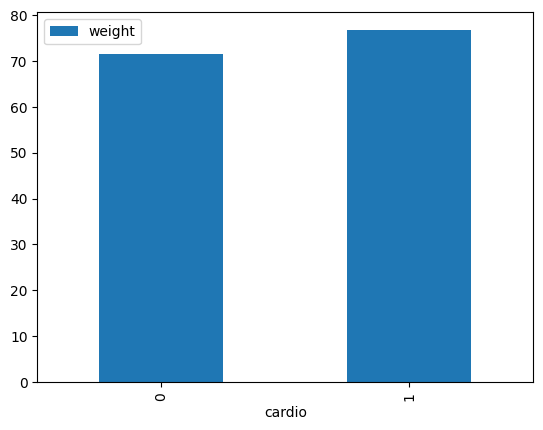

In [ ]:
data.groupby('cardio')[['weight']].agg('mean').plot(kind='bar')

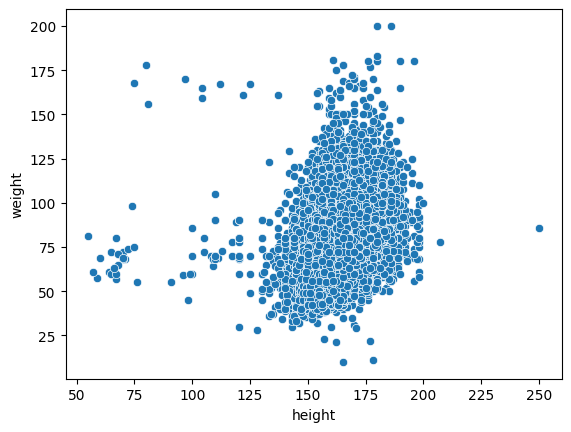

In [ ]:
# scatter plot
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(data=data, x='height', y='weight')
plt.show()

In [ ]:
print(data['height'].corr(data['weight']))

0.2909678349914984
